In [1]:
nums = [2,2,4]
new = []
for i in range(len(nums)-1):
    if nums[i-1] == nums[i]:
        break
    l = nums[i]
    r = nums[i+1]
    if l == r:
        s = l+r
        new.append(s)
    else:
        new.append(l)
print(new)


[4]


In [2]:
from keras import backend as K
from keras import Input
from keras.models import Model
from keras.layers import (
    Dense,
    RNN,
    Layer,
    TimeDistributed,
    SimpleRNN,
    Concatenate,
    Activation,
    Flatten,
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
)
from keras.regularizers import l2
from keras.callbacks import ModelCheckpoint

import keras
import tensorflow as tf

from tqdm import trange
import tqdm
import numpy as np
#import cv2
import pickle
import random
from random import shuffle
import matplotlib.pyplot as plt

In [3]:
f = "splined_trajectories_expanded.txt" # contain 498 trajectories - 0 to 299 - 10, 300 to 498 - 01 - [Lx, Ly, Rx, Ry, Tx, Ty] 

with open(f, "rb") as fp:   #Pickling
        trajectories = np.array(pickle.load(fp))

inp = trajectories[:,:-1,:]
out = trajectories[:,1:,:]
num_inputs = len(inp)
T=inp.shape[1]
hand_signal = np.zeros((num_inputs,T,2),dtype=int)
hand_signal[:num_inputs//2,:,0] = 1
hand_signal[num_inputs//2:,:,1] = 1

def shuffle_XY(x,y,h):
    x,y,h = list(x),list(y),list(h)
    x_sh,y_sh,h_sh = [],[],[]

    ind = list(range(len(y)))
    print(len(ind))
    shuffle(ind)
   
    for i in ind:
        x_sh.append(x[i])
        y_sh.append(y[i])
        h_sh.append(h[i])
   
    x_sh = np.array(x_sh)
    y_sh = np.array(y_sh)
    h_sh = np.array(h_sh)
   
    return x_sh,y_sh,h_sh

shuffled_inp, shuffled_out, shuffled_hand_signal = shuffle_XY(inp, out, hand_signal)


498


In [4]:
print(np.shape(trajectories))
print(np.shape(inp))
print(np.shape(out))
print(num_inputs,T)
print(np.shape(hand_signal))

(498, 21, 4)
(498, 20, 4)
(498, 20, 4)
498 20
(498, 20, 2)


In [5]:
def feedforward_mlp(input_dim, output_dim=1):
    x_in = Input(shape=(input_dim,), name="input")

    x = Dense(128, activation="relu", name="dense_1")(x_in)
    x = Dense(64,  activation="relu", name="dense_2")(x)
    x = Dense(32,  activation="relu", name="dense_3")(x)

    y_out = Dense(output_dim, name="output")(x)

    return Model(x_in, y_out, name="ff_mlp")

def autoregressive_mlp(input_dim, output_dim):
    #x_t = Input(shape=(input_dim,), name="x_t")
    y_prev = Input(shape=(output_dim,), name="y_prev")

    #h = Concatenate(name="concat")([x_t, y_prev])
    h = y_prev
    h = Dense(128, activation="relu", name="dense_1")(h)
    h = Dense(64, activation="relu", name="dense_2")(h)
    h = Dense(32, activation="relu", name="dense_3")(h)

    y_t = Dense(output_dim, name="y_t")(h)

    #return Model([x_t, y_prev], y_t, name="autoregressive_mlp")
    return Model(y_prev, y_t, name="autoregressive_mlp")


In [6]:
input_dim = 4       # number of input features
output_dim = 4      # regression output

model = autoregressive_mlp(input_dim, output_dim)

optimizer = tf.keras.optimizers.Adam(1e-3)
loss_fn = tf.keras.losses.MeanSquaredError()

@tf.function
def train_step(X_seq, Y_seq, tfr):
    """
    X_seq: (N, T, input_dim)
    Y_seq: (N, T, output_dim)
    """

    N = tf.shape(X_seq)[0]
    T = tf.shape(X_seq)[1]

    # initial previous output y[-1]
    y_prev = tf.zeros((N, output_dim),dtype=Y_seq.dtype)

    total_loss = 0.0

    with tf.GradientTape() as tape:
        for t in tf.range(T):
            y_pred = model(y_prev,training=True)

            loss = loss_fn(Y_seq[:, t, :], y_pred)
            total_loss += loss

            # teacher forcing
            use_teacher_forcing = tf.random.uniform([]) < tfr
            y_prev = tf.cond(
                use_teacher_forcing,
                lambda: Y_seq[:, t, :],
                lambda: y_pred
            )

        total_loss /= tf.cast(T, tf.float32)

    grads = tape.gradient(total_loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

    return total_loss

@tf.function
def val_step(X_seq, Y_seq):
    """
    X_seq: (N, T, input_dim)
    Y_seq: (N, T, output_dim)
    """

    N = tf.shape(X_seq)[0]
    T = tf.shape(X_seq)[1]

    # initial previous output y[-1]
    y_prev = tf.zeros(
        (N, output_dim),
        dtype=Y_seq.dtype
    )

    total_loss = 0.0

    for t in tf.range(T):
        y_pred = model(
            y_prev,
            training=False
        )

        loss = loss_fn(Y_seq[:, t, :], y_pred)
        total_loss += loss

        # teacher forcing
        y_prev = y_pred

    total_loss /= tf.cast(T, Y_seq.dtype)
    return total_loss


In [7]:
val_perc = 0.8
val_split = int(val_perc*num_inputs)

X_train = shuffled_inp[:val_split,:,:]
Y_train = shuffled_out[:val_split,:,:]

X_train = X_train.astype("float32")
Y_train = Y_train.astype("float32")

X_val = shuffled_inp[val_split:,:,:]
Y_val = shuffled_out[val_split:,:,:]

X_val = X_val.astype("float32")
Y_val = Y_val.astype("float32")

epochs = 500

pbar = trange(epochs, desc="Training",
            mininterval=0.5,   # seconds between redraws
            smoothing=0.0)      # disables EMA smoothing that causes jitter)
train_loss_history = []
val_loss_history = []
for epoch in pbar:
    tfr = max(0, 1 - epoch/epochs)  # linear decay from 1 to 0
    train_loss = train_step(X_train, Y_train, tfr)
    val_loss   = val_step(X_val, Y_val)
    
    # print(f"Epoch: {epoch} | Train Loss: {train_loss} | Val Loss: {val_loss}")
    # show losses in the tqdm bar instead of print spam
    # tqdm.write(
    #     f"Epoch {epoch} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}"
    # )
    pbar.set_postfix(
        train_loss=f"{train_loss:.6f}",
        val_loss=f"{val_loss:.6f}",
        refresh = False
    )
    train_loss_history.append(train_loss)
    val_loss_history.append(val_loss)



Training:   1%|          | 4/500 [00:07<15:00,  1.82s/it, train_loss=0.041540, val_loss=0.044240]

Training:   1%|          | 5/500 [00:08<13:34,  1.65s/it, train_loss=0.037769, val_loss=0.042394]

Training: 100%|██████████| 500/500 [10:00<00:00,  1.20s/it, train_loss=0.016061, val_loss=0.013944]


Text(0, 0.5, 'Value of Loss')

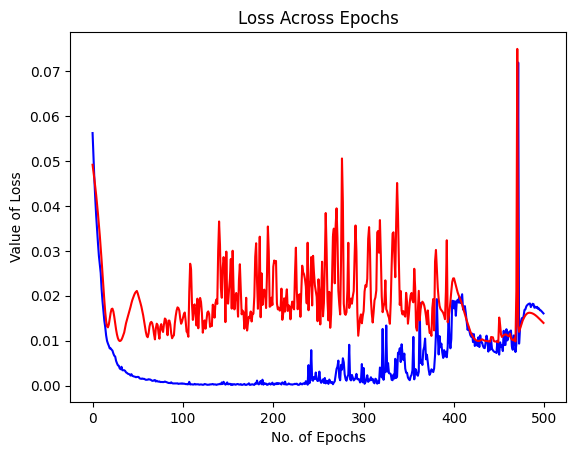

In [8]:
plt.figure()
plt.plot(np.arange(0,epochs),np.array(train_loss_history),color='blue',label='Train Loss')
plt.plot(np.arange(0,epochs),np.array(val_loss_history),color='red',label='Validation Loss')
plt.title("Loss Across Epochs")
plt.xlabel("No. of Epochs")
plt.ylabel("Value of Loss")

In [9]:
model.save("dynamic_model_autoregressive_mlp_v1.keras")